# Assignment 05 — RNN, LSTM and GRU Sequence Classification

## 1. Import Libraries

In [1]:
import time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED=42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Load the IMDB Dataset

In [2]:
VOCAB_SIZE=10000
MAX_LEN=200

(X_train,y_train),(X_test,y_test)=tf.keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print("Training samples:",len(X_train))
print("Testing samples :",len(X_test))
print("Class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples: 25000
Testing samples : 25000
Class distribution:
0    12500
1    12500
Name: count, dtype: int64


The IMDB dataset contains integer-encoded movie reviews with binary sentiment labels: `0 = Negative` and `1 = Positive`.

## 3. Pad Sequences

In [3]:
X_train=tf.keras.utils.pad_sequences(X_train,maxlen=MAX_LEN,padding="post",truncating="post")
X_test=tf.keras.utils.pad_sequences(X_test,maxlen=MAX_LEN,padding="post",truncating="post")
print("X_train:",X_train.shape)
print("X_test :",X_test.shape)

X_train: (25000, 200)
X_test : (25000, 200)


## 4. Build RNN, LSTM and GRU Models

In [4]:
EMBED_DIM=64
UNITS=64

def build_model(layer):
    model=tf.keras.Sequential([
        tf.keras.Input(shape=(MAX_LEN,)),
        tf.keras.layers.Embedding(VOCAB_SIZE,EMBED_DIM),
        layer(UNITS),
        tf.keras.layers.Dense(1,activation="sigmoid")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                  loss="binary_crossentropy",metrics=["accuracy"])
    return model

models={
    "Simple RNN":build_model(tf.keras.layers.SimpleRNN),
    "LSTM":build_model(tf.keras.layers.LSTM),
    "GRU":build_model(tf.keras.layers.GRU)
}

for name,m in models.items():
    print("\n",name)
    m.summary()


 Simple RNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 648,321 (2.47 MB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,025 (2.54 MB)

 Trainable params: 665,025 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

All three models use identical embedding size, recurrent-unit count, optimizer, learning rate, batch size and epochs. Only the recurrent layer changes, making the architectural comparison controlled.

**Architectures**

`Input → Embedding(64) → SimpleRNN(64) → Dense(1)`

`Input → Embedding(64) → LSTM(64) → Dense(1)`

`Input → Embedding(64) → GRU(64) → Dense(1)`

## 5. Train and Evaluate Each Model

In [5]:
EPOCHS=5
BATCH_SIZE=128
results=[]
histories={}

for name,model in models.items():
    print("="*55, "\nTraining:",name)
    start=time.time()
    history=model.fit(X_train,y_train,validation_split=0.10,
                      epochs=EPOCHS,batch_size=BATCH_SIZE,
                      shuffle=True,verbose=1)
    elapsed=time.time()-start
    histories[name]=history

    loss,acc=model.evaluate(X_test,y_test,verbose=0)
    prob=model.predict(X_test,verbose=0).ravel()
    pred=(prob>=0.5).astype(int)

    results.append({
        "Model":name,
        "Test Loss":loss,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":precision_score(y_test,pred,zero_division=0),
        "Recall":recall_score(y_test,pred,zero_division=0),
        "F1-Score":f1_score(y_test,pred,zero_division=0),
        "Training Time (s)":elapsed
    })

results_df=pd.DataFrame(results).sort_values("F1-Score",ascending=False).reset_index(drop=True)
display(results_df.round(4))

Training: Simple RNN
Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 114ms/step - accuracy: 0.5071 - loss: 0.6941 - val_accuracy: 0.4876 - val_loss: 0.6961
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - accuracy: 0.5864 - loss: 0.6666 - val_accuracy: 0.4908 - val_loss: 0.7034
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - accuracy: 0.6698 - loss: 0.5597 - val_accuracy: 0.5072 - val_loss: 0.7878
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 105ms/step - accuracy: 0.7276 - loss: 0.4380 - val_accuracy: 0.5024 - val_loss: 0.9318
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - accuracy: 0.7214 - loss: 0.4472 - val_accuracy: 0.5112 - val_loss: 0.9560
Training: LSTM
Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 65s 356ms/step - accuracy: 0.5362 - loss: 0.6890 - val_accuracy: 0.5428 - val_loss: 0.6882
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 82s 358ms/step - accuracy: 0.5747 - loss: 0.6841 - val_accuracy: 0.5780 - val_loss: 0.6799
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 65s 370ms/step 

,Model,Test Loss,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,GRU,0.4001,0.8259,0.9012,0.7320,0.8078,385.6852
1,LSTM,0.6963,0.5295,0.5420,0.3806,0.4472,335.9691
2,Simple RNN,0.9412,0.4981,0.4969,0.3086,0.3807,101.6962


## 6. Compare Evaluation Metrics

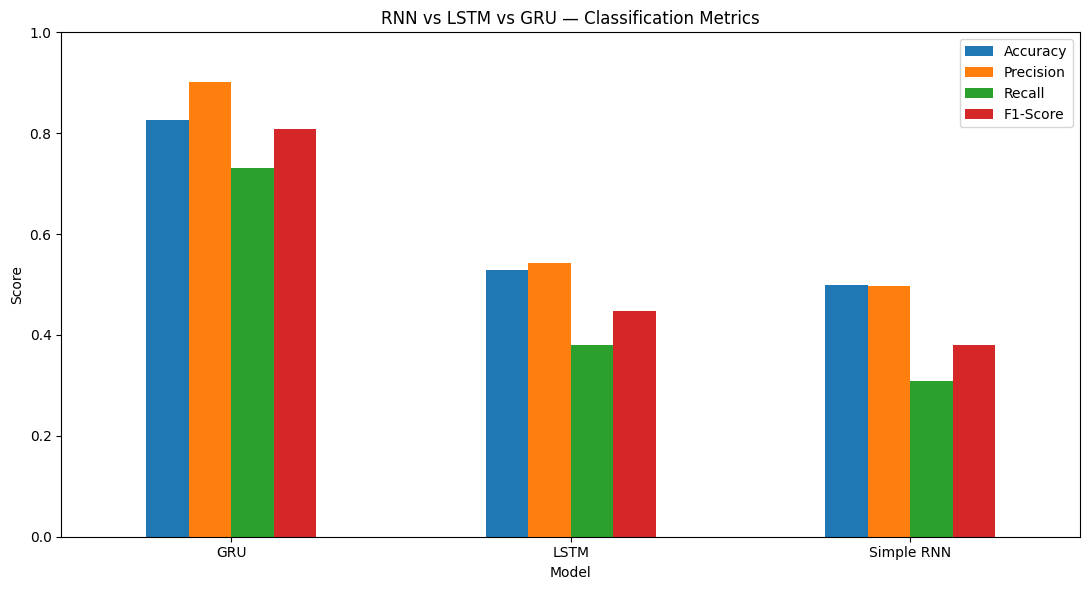

In [6]:
metrics=["Accuracy","Precision","Recall","F1-Score"]
ax=results_df.set_index("Model")[metrics].plot(kind="bar",figsize=(11,6))
ax.set_title("RNN vs LSTM vs GRU — Classification Metrics")
ax.set_ylabel("Score"); ax.set_ylim(0,1)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 7. Compare Validation Accuracy

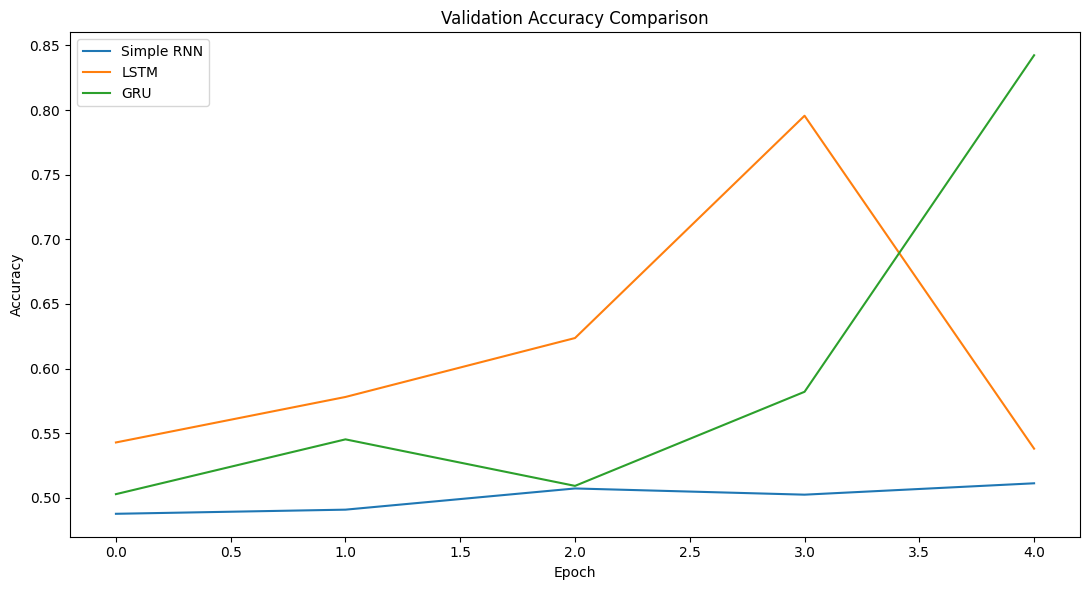

In [7]:
plt.figure(figsize=(11,6))
for name,h in histories.items():
    plt.plot(h.history["val_accuracy"],label=name)
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
plt.tight_layout(); plt.show()

## 8. Confusion Matrix for the Best Model

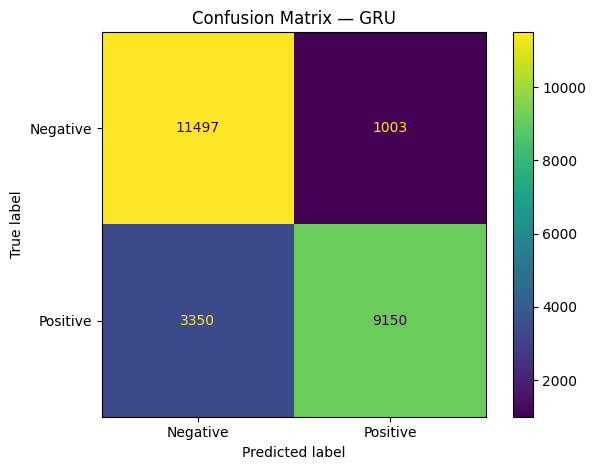

              precision    recall  f1-score   support

    Negative     0.7744    0.9198    0.8408     12500
    Positive     0.9012    0.7320    0.8078     12500

    accuracy                         0.8259     25000
   macro avg     0.8378    0.8259    0.8243     25000
weighted avg     0.8378    0.8259    0.8243     25000



In [8]:
best_name=results_df.iloc[0]["Model"]
best_model=models[best_name]
prob=best_model.predict(X_test,verbose=0).ravel()
pred=(prob>=0.5).astype(int)

cm=confusion_matrix(y_test,pred)
ConfusionMatrixDisplay(cm,display_labels=["Negative","Positive"]).plot()
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout(); plt.show()

print(classification_report(y_test,pred,target_names=["Negative","Positive"],digits=4))

## 9. Final Comparison

In [9]:
display(results_df[["Model","Accuracy","Precision","Recall","F1-Score","Test Loss","Training Time (s)"]].round(4))
print("Best model by F1-score:",results_df.iloc[0]["Model"])

,Model,Accuracy,Precision,Recall,F1-Score,Test Loss,Training Time (s)
0,GRU,0.8259,0.9012,0.7320,0.8078,0.4001,385.6852
1,LSTM,0.5295,0.5420,0.3806,0.4472,0.6963,335.9691
2,Simple RNN,0.4981,0.4969,0.3086,0.3807,0.9412,101.6962


Best model by F1-score: GRU


## 10. Conclusion

The experiment compares Simple RNN, LSTM and GRU under the same data and training configuration. Accuracy, Precision, Recall, F1-score, test loss and training time are used together to assess predictive quality and computational cost.

The final winner should be determined from the generated test metrics rather than assumed in advance. Run all cells to obtain the actual results for the execution environment.